In [25]:
import os
import sqlite3

import pandas as pd
from pycaret.classification import *

from features import label_encoder
from utilities import get_path, read_data_from_database

In [26]:
pd.options.display.max_columns = None  # Remove "dots" from display when printing dataframes

In [27]:
PATH = get_path(1)
DATABASE_FOLDER = PATH + 'data/preprocessing/BANCO_BOGOTA.db'

In [28]:
df_train = read_data_from_database(DATABASE_FOLDER, 'prep_train_data')
df_test = read_data_from_database(DATABASE_FOLDER, 'prep_test_data')

In [29]:
df_train.head()

,ID,Edad,Tipo_Trabajo,Estado_Civil,Educacion,mora,Vivienda,Consumo,Contacto,Mes,Dia,Campana,Dias_Ultima_Camp,No_Contactos,Resultado_Anterior,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,1,57,servicios,casado,bachillerato,0.0,0.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
1,2,37,servicios,casado,bachillerato,0.0,1.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
2,3,40,administrador negocio,casado,primaria,0.0,0.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
3,4,56,servicios,casado,bachillerato,0.0,0.0,1.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
4,7,25,servicios,soltero,bachillerato,0.0,1.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0


# Label encoder

In [30]:
labels_to_encoders_name = {
    'Tipo_Trabajo':'Tipo_Trabajo_ENC',
    'Estado_Civil':'Estado_Civil_ENC',
    'Educacion':'Educacion_ENC',    
    'Contacto':'Contacto_ENC',
    'Mes':'Mes_ENC',
    'Dia':'Dia_ENC',
    'Resultado_Anterior':'Resultado_Anterior_ENC'
    }

for var_encoder, encoder_name in labels_to_encoders_name.items():
    label_encoder(var_encoder, encoder_name, df_train)
    label_encoder(var_encoder, encoder_name, df_test)

In [31]:
df_train[[
    'Tipo_Trabajo', 'Tipo_Trabajo_ENC', 'Estado_Civil', 'Estado_Civil_ENC',
    'Educacion', 'Educacion_ENC', 'Contacto', 'Contacto_ENC', 'Mes', 'Mes_ENC',
    'Dia', 'Dia_ENC','Resultado_Anterior', 'Resultado_Anterior_ENC'
    ]].sample(n=10).head(10)

,Tipo_Trabajo,Tipo_Trabajo_ENC,Estado_Civil,Estado_Civil_ENC,Educacion,Educacion_ENC,Contacto,Contacto_ENC,Mes,Mes_ENC,Dia,Dia_ENC,Resultado_Anterior,Resultado_Anterior_ENC
21095,administrador negocio,0,soltero,2,pregrado,5,celular,0,ago,1,lun,1,fallido,0
19036,empleado,3,divorciado,1,bachillerato incompleto,1,celular,0,may,6,mié,3,sin contacto,2
10154,ama de casa,1,divorciado,1,pregrado,5,celular,0,jul,3,mar,2,sin contacto,2
17938,administrador negocio,0,casado,0,pregrado,5,celular,0,may,6,jue,0,fallido,0
128,empleado,3,casado,0,preescolar,4,telefono fijo,1,may,6,lun,1,sin contacto,2
20677,tecnico,8,casado,0,pregrado,5,celular,0,jun,4,lun,1,sin contacto,2
22374,ama de casa,1,casado,0,bachillerato,0,celular,0,jun,4,vie,4,sin contacto,2
13869,empleado,3,casado,0,bachillerato,0,celular,0,nov,7,lun,1,sin contacto,2
19536,estudiante,5,soltero,2,pregrado,5,celular,0,may,6,jue,0,sin contacto,2
16143,empleado,3,soltero,2,preescolar,4,celular,0,abr,0,jue,0,sin contacto,2


# Auto Machine Learning

In [32]:
df_new = df_train[[
    'Edad', 'Tipo_Trabajo_ENC', 'Estado_Civil_ENC', 'Educacion_ENC', 
    'mora', 'Vivienda', 'Consumo', 'Contacto_ENC', 'Mes_ENC', 'Dia_ENC', 
    'Campana', 'Dias_Ultima_Camp', 'No_Contactos', 'Resultado_Anterior_ENC',
    'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed',
    'y'
    ]].copy()

df_new.head()

,Edad,Tipo_Trabajo_ENC,Estado_Civil_ENC,Educacion_ENC,mora,Vivienda,Consumo,Contacto_ENC,Mes_ENC,Dia_ENC,Campana,Dias_Ultima_Camp,No_Contactos,Resultado_Anterior_ENC,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,57,7,0,0,0.0,0.0,0.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0
1,37,7,0,0,0.0,1.0,0.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0
2,40,0,0,6,0.0,0.0,0.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0
3,56,7,0,0,0.0,0.0,1.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0
4,25,7,2,0,0.0,1.0,0.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0


In [33]:
data = df_new.sample(frac=0.8, random_state=0)
data_unseen = df_train.drop(data.index)

In [34]:
data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)
print(f'Datos para modelar: {data.shape}; y datos para predecir: {data_unseen.shape}')

Datos para modelar: (18479, 20); y datos para predecir: (4620, 28)


In [35]:
model_setup = setup(data=data, target='y')

,Description,Value
0,Session id,2662
1,Target,y
2,Target type,Binary
3,Original data shape,"(18479, 20)"
4,Transformed data shape,"(18479, 30)"
5,Transformed train set shape,"(12935, 30)"
6,Transformed test set shape,"(5544, 30)"
7,Numeric features,17
8,Categorical features,2
9,Preprocess,True


In [36]:
models()  # Modelos suportados

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [37]:
best_models = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)


In [38]:
ada = create_model('ada')
print(ada)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8887,0.7662,0.2245,0.5238,0.3143,0.2641,0.2924
1,0.8988,0.7785,0.2449,0.6429,0.3547,0.3115,0.3547
2,0.8988,0.7984,0.2041,0.6818,0.3141,0.2763,0.3360
3,0.8980,0.7699,0.1769,0.7027,0.2826,0.2483,0.3185
4,0.9034,0.7932,0.2041,0.7895,0.3243,0.2912,0.3705
5,0.8987,0.7648,0.2055,0.6667,0.3141,0.2756,0.3322
6,0.8956,0.7979,0.2260,0.6000,0.3284,0.2841,0.3244
7,0.8871,0.7412,0.1973,0.5088,0.2843,0.2358,0.2673
8,0.8956,0.7351,0.2449,0.6000,0.3478,0.3018,0.3380


AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=2662)


In [39]:
ada = create_model('ada')
print(ada)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8887,0.7662,0.2245,0.5238,0.3143,0.2641,0.2924
1,0.8988,0.7785,0.2449,0.6429,0.3547,0.3115,0.3547
2,0.8988,0.7984,0.2041,0.6818,0.3141,0.2763,0.3360
3,0.8980,0.7699,0.1769,0.7027,0.2826,0.2483,0.3185
4,0.9034,0.7932,0.2041,0.7895,0.3243,0.2912,0.3705
5,0.8987,0.7648,0.2055,0.6667,0.3141,0.2756,0.3322
6,0.8956,0.7979,0.2260,0.6000,0.3284,0.2841,0.3244
7,0.8871,0.7412,0.1973,0.5088,0.2843,0.2358,0.2673
8,0.8956,0.7351,0.2449,0.6000,0.3478,0.3018,0.3380


AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=2662)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8980,0.7730,0.1905,0.6829,0.2979,0.2613,0.3245
1,0.9003,0.7738,0.1565,0.8214,0.2629,0.2350,0.3317
2,0.8980,0.7916,0.1633,0.7273,0.2667,0.2348,0.3128
3,0.9003,0.7632,0.1633,0.8000,0.2712,0.2420,0.3332
4,0.9019,0.7865,0.1769,0.8125,0.2905,0.2605,0.3507
5,0.9010,0.7498,0.1644,0.8000,0.2727,0.2436,0.3346
6,0.8925,0.7813,0.1712,0.5814,0.2646,0.2247,0.2745
7,0.8940,0.7314,0.1565,0.6389,0.2514,0.2163,0.2800
8,0.8971,0.7212,0.1769,0.6842,0.2811,0.2459,0.3127


Fitting 10 folds for each of 10 candidates, totalling 100 fits


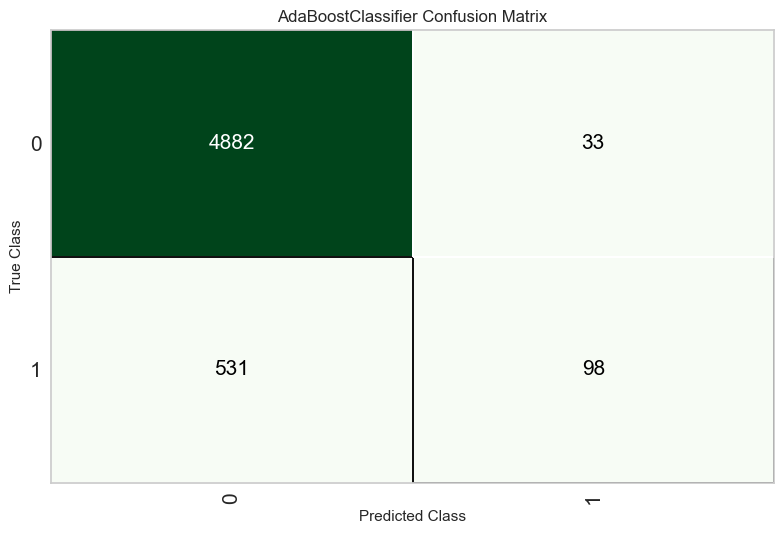

In [40]:
tuned_ada = tune_model(ada)
plot_model(tuned_ada, plot='confusion_matrix')

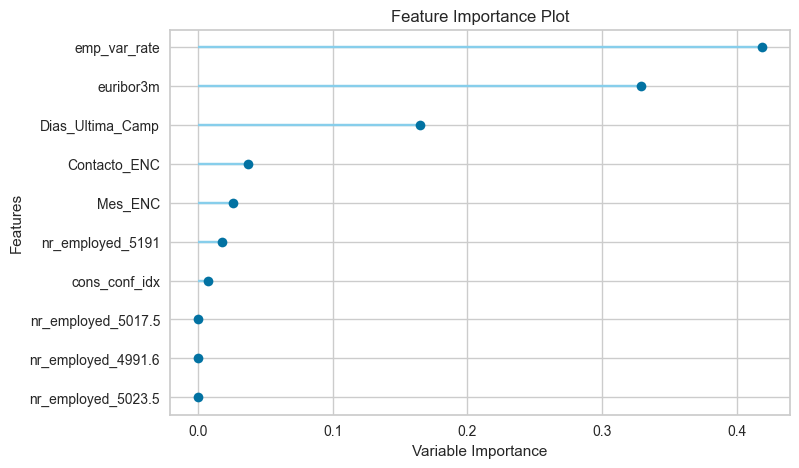

In [41]:
plot_model(tuned_ada, plot='feature')

In [42]:
unseen_predictions = predict_model(tuned_ada, data=data_unseen)
unseen_predictions[['y', 'prediction_label', 'prediction_score']].sample(n=25).head(25)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.9013,0.7901,0.1501,0.6667,0.2450,0.2142,0.2846


,y,prediction_label,prediction_score
1040,0,0,0.8668
3904,1,0,0.7607
4160,0,1,0.5541
3295,0,0,0.7725
4117,0,0,0.7411
4425,1,1,0.5368
2269,0,0,0.8575
4337,1,0,0.6432
793,0,0,0.8808
1025,0,0,0.8668


In [43]:
final_ada = finalize_model(tuned_ada)
print(final_ada)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Edad', 'Tipo_Trabajo_ENC',
                                             'Estado_Civil_ENC',
                                             'Educacion_ENC', 'mora',
                                             'Vivienda', 'Consumo',
                                             'Contacto_ENC', 'Mes_ENC',
                                             'Dia_ENC', 'Dias_Ultima_Camp',
                                             'No_Contactos',
                                             'Resultado_Anterior_ENC',
                                             'emp_var_rate', 'cons_price_idx',
                                             'cons_conf_idx', 'euribor3m']...
                 TransformerWrapper(exclude=None, include=['Campana'],
                                    transformer=TargetEncoder(cols=['Campana'],
         

# Save model

In [44]:
save_model(final_ada, PATH + 'data/salida/ADA_model_02-05-2024')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Edad', 'Tipo_Trabajo_ENC',
                                              'Estado_Civil_ENC',
                                              'Educacion_ENC', 'mora',
                                              'Vivienda', 'Consumo',
                                              'Contacto_ENC', 'Mes_ENC',
                                              'Dia_ENC', 'Dias_Ultima_Camp',
                                              'No_Contactos',
                                              'Resultado_Anterior_ENC',
                                              'emp_var_rate', 'cons_price_idx',
                                              'cons_conf_idx', 'euribor3m']...
                  TransformerWrapper(exclude=None, include=['Campana'],
                                     transformer=TargetEncoder(cols=['Campa

# Deploy

In [45]:
ada_model = load_model(PATH + 'data/salida/ADA_model_02-05-2024')

Transformation Pipeline and Model Successfully Loaded


In [46]:
df_implement = predict_model(ada_model, data=df_test)
df_implement = df_implement.rename({
    'prediction_label':'y'
    }, axis=1)

In [48]:
df_implement.head()

0.8169438690717471

# Save data

In [ ]:
# Load to DataBase
try:
    # Create a connection to the SQLite database
    conn = sqlite3.connect(os.path.join(PATH, 'data', 'preprocessing', 'BANCO_BOGOTA.db'))

    df_implement.to_sql(
    'TechnicalTest_DS_AMT', conn, index=False, if_exists='replace'    
    )
    # Commit changes
    conn.commit()
    print('Data loaded successfully to the database.')
except Exception as e:
    print(f'An error occurred while loading data to the database: {str(e)}')
    if conn is not None:
        conn.rollback()
finally:
    # Close connection
    if conn is not None:
        conn.close()
        print('Database connection closed.')

In [ ]:
del df_train, df_test, df_new, df_implement  # Delete variables to free memory